In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Dataset .csv")

In [2]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9542 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9542 non-null   int64  
 1   Restaurant Name       9542 non-null   object 
 2   Country Code          9542 non-null   int64  
 3   City                  9542 non-null   object 
 4   Address               9542 non-null   object 
 5   Locality              9542 non-null   object 
 6   Locality Verbose      9542 non-null   object 
 7   Longitude             9542 non-null   float64
 8   Latitude              9542 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9542 non-null   int64  
 11  Currency              9542 non-null   object 
 12  Has Table booking     9542 non-null   object 
 13  Has Online delivery   9542 non-null   object 
 14  Is delivering now     9542 non-null   object 
 15  Switch to order menu  9542

In [6]:
count = 0
for i in df.duplicated():
    if(i):
        count += 1
count

0

In [7]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.542000e+03,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000
mean,9.043301e+06,18.179208,64.274997,25.848532,1200.326137,1.804968,2.665238,156.772060
std,8.791967e+06,56.451600,41.197602,11.010094,16128.743876,0.905563,1.516588,430.203324
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019312e+05,1.000000,77.081565,28.478658,250.000000,1.000000,2.500000,5.000000
50%,6.002726e+06,1.000000,77.192031,28.570444,400.000000,2.000000,3.200000,31.000000
75%,1.835260e+07,1.000000,77.282043,28.642711,700.000000,2.000000,3.700000,130.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [8]:
x = df.drop("Aggregate rating", axis = 1)
y = df["Aggregate rating"]

In [9]:
drop_col = ["Restaurant ID",
            "Restaurant Name",
            "Address",
            "Locality Verbose"]
x = x.drop(columns=drop_col)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [11]:
num_cols = ["Country Code", "Longitude", "Latitude", "Average Cost for two", "Price range", "Votes"]
cat_cols = ["City", "Locality", "Cuisines", "Currency", "Has Table booking", "Has Online delivery", "Is delivering now",
            "Switch to order menu", "Rating color", "Rating text"]

In [12]:
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), 
                             ("scaler", StandardScaler())])
categorical_pipeline = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), 
                                 ("encoder", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([('num', numeric_pipeline, num_cols), ('cat', categorical_pipeline, cat_cols)])

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.2, random_state=42)

In [14]:
result = []

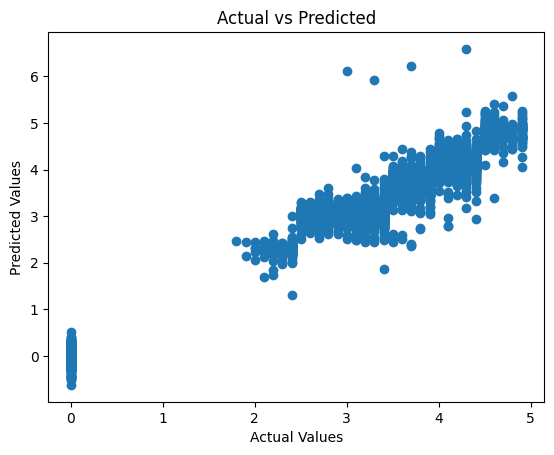

In [15]:
from sklearn.linear_model import LinearRegression
lin_model = Pipeline(steps=[("preprocess", preprocess),
                ("regressor", LinearRegression())
])
lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
result.append({
        "Model": "Linear Regression",
        "R2": r2_score(y_test, y_pred),
        "RMSE":  mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

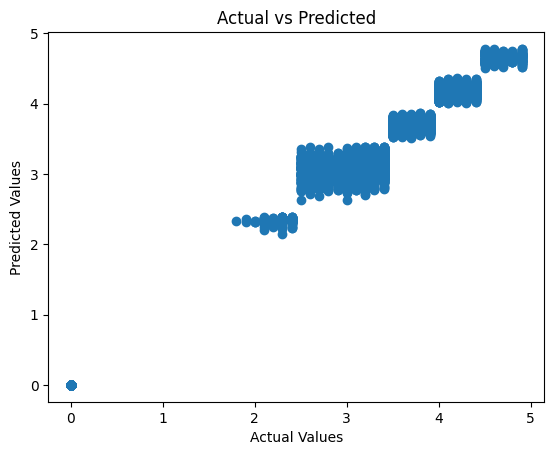

In [16]:
from sklearn.ensemble import RandomForestRegressor
rf_model = Pipeline(steps=[("preprocess", preprocess),
                ("regressor", RandomForestRegressor(n_estimators=300, random_state=42))
])
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)
result.append({
        "Model": "Random Forest",
        "R2": r2_score(y_test, y_pred),
        "RMSE":  mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

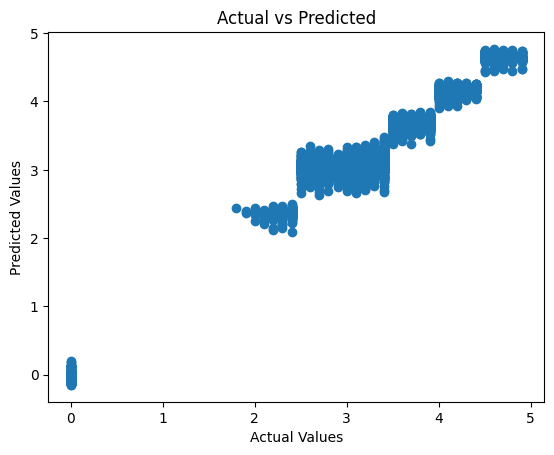

In [17]:
from sklearn.ensemble import GradientBoostingRegressor
gbr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ))
])
gbr_model.fit(x_train, y_train)
y_pred = gbr_model.predict(x_test)
result.append({
        "Model": "Gradient Boosting",
        "R2": r2_score(y_test, y_pred),
        "RMSE":  mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

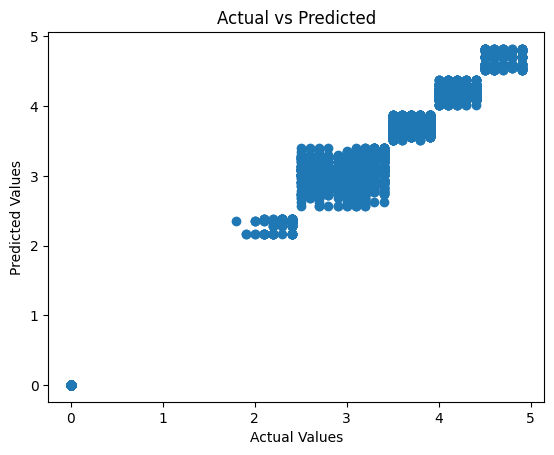

In [18]:
from sklearn.tree import DecisionTreeRegressor
dt_model = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("regressor", DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ))
])
dt_model.fit(x_train, y_train)
y_pred = dt_model.predict(x_test)
result.append({
        "Model": "Decision Tree",
        "R2": r2_score(y_test, y_pred),
        "RMSE":  mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    })
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [19]:
result

[{'Model': 'Linear Regression',
  'R2': 0.975627684698571,
  'RMSE': 0.05584796458265805,
  'MAE': 0.16989802696467793},
 {'Model': 'Random Forest',
  'R2': 0.9865415680371596,
  'RMSE': 0.030839336448053856,
  'MAE': 0.11822504584752423},
 {'Model': 'Gradient Boosting',
  'R2': 0.9867422134501593,
  'RMSE': 0.030379567329679405,
  'MAE': 0.12257133798668224},
 {'Model': 'Decision Tree',
  'R2': 0.9853065782379338,
  'RMSE': 0.033669254972990434,
  'MAE': 0.12495607943113449}]

In [20]:
results_df = pd.DataFrame(result)
results_df.sort_values(by="R2", ascending=False)

,Model,R2,RMSE,MAE
2,Gradient Boosting,0.986742,0.030380,0.122571
1,Random Forest,0.986542,0.030839,0.118225
3,Decision Tree,0.985307,0.033669,0.124956
0,Linear Regression,0.975628,0.055848,0.169898


In [21]:
from sklearn.model_selection import cross_val_score
models = {
    "Linear Regression": lin_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gbr_model
}
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, x, y,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    cv_results[name] = scores.mean()
cv_results

{'Linear Regression': np.float64(0.9575197915837101),
 'Decision Tree': np.float64(0.985079201903123),
 'Random Forest': np.float64(0.9856569884386323),
 'Gradient Boosting': np.float64(0.9864682478057551)}

In [22]:
best_model = max(cv_results, key=cv_results.get)
print("Best Model:", best_model)
print("Best CV R2:", cv_results[best_model])

Best Model: Gradient Boosting
Best CV R2: 0.9864682478057551
